# DMML — Seizure & Depression Classification
Short: EEG seizure detection and depression classification (survey-based).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, ConfusionMatrixDisplay
)

from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import zscore, ttest_rel
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

### Imports & setup
Load libraries and plotting configuration.

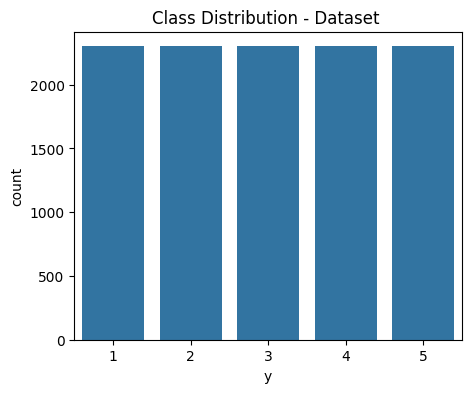

In [3]:
df1 = pd.read_csv("Data/Epileptic Seizure Recognition.csv")
plt.figure(figsize=(5,4))
sns.countplot(x=df1["y"])
plt.title("Class Distribution - Dataset ")
plt.show()


### Data loading
Load EEG and depression datasets; initial inspection.

In [4]:
df1 = df1.drop("Unnamed", axis=1, errors='ignore')
df1 = df1.fillna(df1.median())
X1 = df1.drop("y", axis=1)
y1 = df1["y"]


### Preprocessing
Cleaning, scaling, encoding, and sampling (SMOTE) steps.

In [5]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, stratify=y1, random_state=42
)

# Handle imbalance
sm = SMOTE()
X1_train, y1_train = sm.fit_resample(X1_train, y1_train)

In [6]:
y1_train_mapped = y1_train - 1
y1_test_mapped = y1_test - 1

xgb_final = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=10,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    random_state=42
)

print("Training XGBoost...")
xgb_final.fit(X1_train, y1_train_mapped)

xgb_acc = accuracy_score(y1_test_mapped, xgb_final.predict(X1_test))
print(f"XGBoost Accuracy: {xgb_acc*100:.2f}%")

Training XGBoost...
XGBoost Accuracy: 74.43%


### Seizure models
Train XGBoost and 1D-CNN on EEG data.

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau

X_train_cnn = X1_train.values.reshape(X1_train.shape[0], X1_train.shape[1], 1)
X_test_cnn = X1_test.values.reshape(X1_test.shape[0], X1_test.shape[1], 1)

cnn_model = models.Sequential([
    layers.Conv1D(64, 3, activation="relu", input_shape=(178, 1)),
    layers.BatchNormalization(),
    layers.MaxPool1D(2),
    layers.Dropout(0.3),
    layers.Conv1D(128, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPool1D(2),
    layers.Dropout(0.4),
    layers.Conv1D(256, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(5, activation="softmax")
])

cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=0.00001, verbose=1)

print("Training 1D-CNN (50 epochs with LR scheduler)...")
cnn_model.fit(X_train_cnn, y1_train_mapped, epochs=50, batch_size=32, verbose=0, validation_split=0.1, callbacks=[lr_scheduler])

_, cnn_acc = cnn_model.evaluate(X_test_cnn, y1_test_mapped, verbose=0)
print(f"1D-CNN Accuracy: {cnn_acc*100:.2f}%")

Training 1D-CNN (50 epochs with LR scheduler)...

Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 45: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1D-CNN Accuracy: 83.74%


In [8]:
# Function to evaluate classification models (XGBoost, etc.)
def evaluate_clf_sklearn_like(model, X_test, y_test_mapped_labels):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) # Get probabilities for all classes

    print("Accuracy:", accuracy_score(y_test_mapped_labels, y_pred))
    print("Precision:", precision_score(y_test_mapped_labels, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test_mapped_labels, y_pred, average='weighted'))
    print("F1:", f1_score(y_test_mapped_labels, y_pred, average='weighted'))
    # Calculate multiclass ROC-AUC using OvR strategy
    print("ROC-AUC:", roc_auc_score(y_test_mapped_labels, y_proba, multi_class='ovr', average='weighted'))

    return y_pred, y_proba

# Function to evaluate Keras CNN models
def evaluate_clf_cnn(model, X_test_cnn, y_test_mapped_labels):
    y_proba = model.predict(X_test_cnn) # Keras predict returns probabilities for classification
    y_pred = np.argmax(y_proba, axis=1)

    print("Accuracy:", accuracy_score(y_test_mapped_labels, y_pred))
    print("Precision:", precision_score(y_test_mapped_labels, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test_mapped_labels, y_pred, average='weighted'))
    print("F1:", f1_score(y_test_mapped_labels, y_pred, average='weighted'))
    # Calculate multiclass ROC-AUC using OvR strategy
    print("ROC-AUC:", roc_auc_score(y_test_mapped_labels, y_proba, multi_class='ovr', average='weighted'))

    return y_pred, y_proba

print("XGBoost Classifier")
xgb_pred, xgb_proba = evaluate_clf_sklearn_like(xgb_final, X1_test, y1_test_mapped)

print("\n1D-CNN Classifier")
cnn_pred, cnn_proba = evaluate_clf_cnn(cnn_model, X_test_cnn, y1_test_mapped)

XGBoost Classifier
Accuracy: 0.7443478260869565
Precision: 0.7468113030610014
Recall: 0.7443478260869565
F1: 0.7435761756681114
ROC-AUC: 0.9382861531190927

1D-CNN Classifier
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Accuracy: 0.837391304347826
Precision: 0.8408062743604592
Recall: 0.837391304347826
F1: 0.8380751384551351
ROC-AUC: 0.9746696597353497


### Seizure evaluation
Confusion matrix, ROC, and feature importance for seizure models.

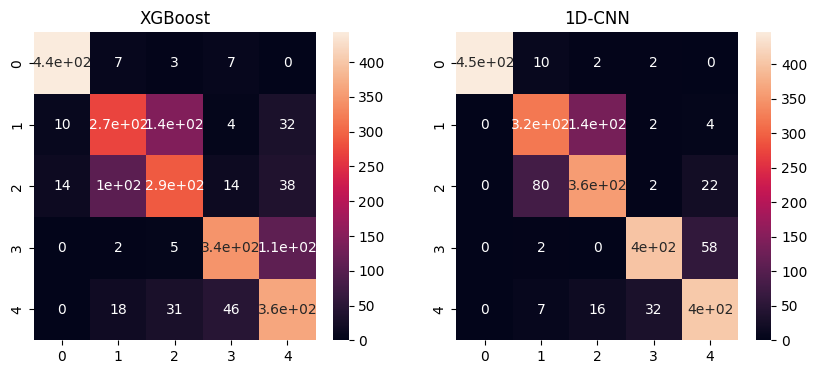

In [9]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.heatmap(confusion_matrix(y1_test_mapped, xgb_pred), annot=True, ax=ax[0])
ax[0].set_title("XGBoost")

sns.heatmap(confusion_matrix(y1_test_mapped, cnn_pred), annot=True, ax=ax[1])
ax[1].set_title("1D-CNN")

plt.show()

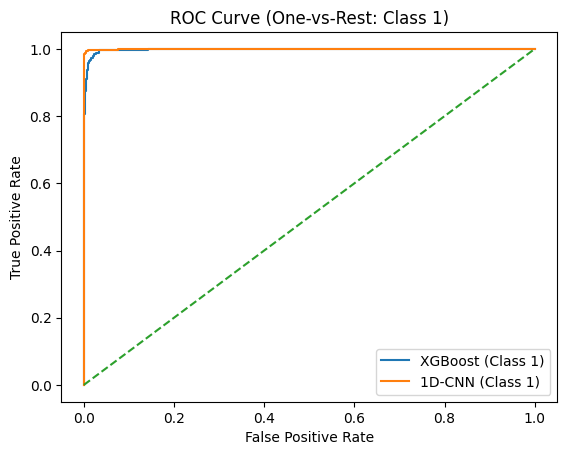

In [10]:
from sklearn.preprocessing import label_binarize

# Binarize the output for Class 1 vs Rest
target_class = 0 # Corresponds to original class 1
y_test_binarized = (y1_test_mapped == target_class).astype(int)

# Get probabilities for the target class (index 'target_class')
xgb_prob_c1 = xgb_proba[:, target_class]
cnn_prob_c1 = cnn_proba[:, target_class]

fpr_xgb, tpr_xgb, _ = roc_curve(y_test_binarized, xgb_prob_c1)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test_binarized, cnn_prob_c1)

plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (Class {target_class+1})")
plt.plot(fpr_cnn, tpr_cnn, label=f"1D-CNN (Class {target_class+1})")
plt.plot([0,1],[0,1],'--')

plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f"ROC Curve (One-vs-Rest: Class {target_class+1})")
plt.show()

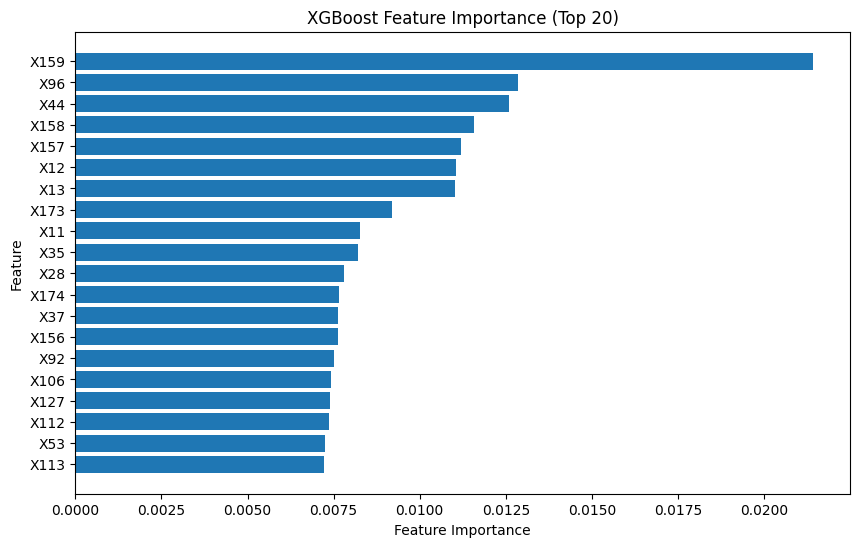

In [11]:
importances = xgb_final.feature_importances_

plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
# Sort importances and get feature names for better visualization
sorted_idx = importances.argsort()[::-1]

# Plot top N features for clarity, e.g., top 20
top_n = 20
plt.barh(range(top_n), importances[sorted_idx][:top_n])
plt.yticks(range(top_n), X1_train.columns[sorted_idx][:top_n])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance (Top 20)")
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

In [12]:
import pandas as pd

# Take a 20% sample to speed up cross-validation
subset_X = X1_train.sample(frac=0.2, random_state=42)
subset_y = y1_train_mapped.loc[subset_X.index]

print(f'Running CV on subset of size: {subset_X.shape[0]}...')
scores_xgb = cross_val_score(xgb_final, subset_X, subset_y, cv=3, scoring='f1_weighted', n_jobs=-1)
print("XGBoost Mean F1 (weighted) on subset:", scores_xgb.mean())

Running CV on subset of size: 1840...
XGBoost Mean F1 (weighted) on subset: 0.5723029463973109


In [13]:
df2 = pd.read_csv("Data/final_depression_dataset_1.csv")

In [14]:
import numpy as np
from scipy.stats import zscore

print("Available columns:", df2.columns.tolist())

# Select only numeric columns for cleaning
numeric_cols = df2.select_dtypes(include=[np.number]).columns
df2[numeric_cols] = df2[numeric_cols].fillna(df2[numeric_cols].median())

# Filter outliers
z = np.abs(zscore(df2[numeric_cols]))
df2 = df2[(z < 3).all(axis=1)]

# Setup target and features
target_col = 'Depression'
X2 = df2.drop(target_col, axis=1)
y2 = df2[target_col]
print(f"Target '{target_col}' prepared.")

Available columns: ['Name', 'Gender', 'Age', 'City', 'Working Professional or Student', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']
Target 'Depression' prepared.


In [15]:
# Split and Scale
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)

# Only use numeric features for the current models
numeric_features = X2.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()

X2_train_numeric = scaler.fit_transform(X2_train[numeric_features])
X2_test_numeric = scaler.transform(X2_test[numeric_features])

# Map target to 0 and 1
y2_train_clf = y2_train.map({'Yes': 1, 'No': 0})
y2_test_clf = y2_test.map({'Yes': 1, 'No': 0})

### Categorical Encoding
Encode categorical features and apply SMOTE to the training set.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np
cat_cols = X2.select_dtypes(include=['object']).columns
numeric_cols = X2.select_dtypes(exclude=['object']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
X2_train_proc = preprocessor.fit_transform(X2_train)
X2_test_proc = preprocessor.transform(X2_test)
smote_dep = SMOTE(random_state=42)
X2_train_res, y2_train_res = smote_dep.fit_resample(X2_train_proc, y2_train_clf)


In [17]:
# Retrain models with categorical data
print("Training XGBoost with Categorical Features...")
xgb_cat = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb_cat.fit(X2_train_res, y2_train_res)

print("Training MLP with Categorical Features...")
mlp_cat = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
mlp_cat.fit(X2_train_res, y2_train_res)


print("\nUpdated XGBoost Report:")
print(classification_report(y2_test_clf, xgb_cat.predict(X2_test_proc)))

print("\nUpdated MLP Report:")
print(classification_report(y2_test_clf, mlp_cat.predict(X2_test_proc)))

Training XGBoost with Categorical Features...
Training MLP with Categorical Features...

Updated XGBoost Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       385
           1       0.74      0.81      0.77        57

    accuracy                           0.94       442
   macro avg       0.86      0.88      0.87       442
weighted avg       0.94      0.94      0.94       442


Updated MLP Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       385
           1       0.81      0.84      0.83        57

    accuracy                           0.95       442
   macro avg       0.90      0.91      0.90       442
weighted avg       0.96      0.95      0.96       442



In [34]:
# Split and Scale
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)

# Only use numeric features for the current models
numeric_features = X2.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()

X2_train_numeric = scaler.fit_transform(X2_train[numeric_features])
X2_test_numeric = scaler.transform(X2_test[numeric_features])

# Map target to 0 and 1
y2_train_clf = y2_train.map({'Yes': 1, 'No': 0})
y2_test_clf = y2_test.map({'Yes': 1, 'No': 0})

In [19]:
from imblearn.over_sampling import SMOTE
smote_num = SMOTE(random_state=42)
X2_train_resampled, y2_train_resampled = smote_num.fit_resample(X2_train_numeric, y2_train_clf)
# Retrain XGBoost on resampled data
xgb_dep_balanced = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb_dep_balanced.fit(X2_train_resampled, y2_train_resampled)
# Retrain MLP on resampled data
mlp_dep_balanced = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_dep_balanced.fit(X2_train_resampled, y2_train_resampled)
print("Models retrained on balanced data.")


Models retrained on balanced data.


In [20]:
print("XGBoost (Balanced) Report:")
print(classification_report(y2_test_clf, xgb_dep_balanced.predict(X2_test_numeric)))

print("\nMLP (Balanced) Report:")
print(classification_report(y2_test_clf, mlp_dep_balanced.predict(X2_test_numeric)))

XGBoost (Balanced) Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       385
           1       0.56      0.70      0.62        57

    accuracy                           0.89       442
   macro avg       0.75      0.81      0.78       442
weighted avg       0.90      0.89      0.89       442


MLP (Balanced) Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       385
           1       0.56      0.70      0.62        57

    accuracy                           0.89       442
   macro avg       0.76      0.81      0.78       442
weighted avg       0.90      0.89      0.90       442



In [35]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Optimize XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    random_state=42
)

print("Optimizing XGBoost...")
xgb_search.fit(X2_train_resampled, y2_train_resampled)
xgb_best = xgb_search.best_estimator_

# 2. Optimize MLP

mlp_optimized = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

print("Training Optimized MLP...")
mlp_optimized.fit(X2_train_resampled, y2_train_resampled)

print("Optimization Complete.")

Optimizing XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Training Optimized MLP...
Optimization Complete.


### Depression models
Train XGBoost and MLP on depression dataset with encoding and scaling.

In [22]:
print("Optimized XGBoost Report:")
print(classification_report(y2_test_clf, xgb_best.predict(X2_test_numeric)))

print("\nOptimized MLP Report:")
print(classification_report(y2_test_clf, mlp_optimized.predict(X2_test_numeric)))

Optimized XGBoost Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       385
           1       0.58      0.68      0.63        57

    accuracy                           0.90       442
   macro avg       0.77      0.81      0.78       442
weighted avg       0.90      0.90      0.90       442


Optimized MLP Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       385
           1       0.55      0.74      0.63        57

    accuracy                           0.89       442
   macro avg       0.75      0.82      0.78       442
weighted avg       0.91      0.89      0.89       442



In [23]:
import xgboost as xgb

# 1. XGBoost Classifier
xgb_dep = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb_dep.fit(X2_train_numeric, y2_train_clf)

print("XGBoost Model Trained Successfully.")

XGBoost Model Trained Successfully.


In [24]:
mlp_dep = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_dep.fit(X2_train_numeric, y2_train_clf)

print("MLP Model Trained Successfully.")

MLP Model Trained Successfully.


In [25]:
from sklearn.metrics import classification_report

print("XGBoost Classification Report:")
print(classification_report(y2_test_clf, xgb_dep.predict(X2_test_numeric)))

print("\nMLP Classification Report:")
print(classification_report(y2_test_clf, mlp_dep.predict(X2_test_numeric)))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       385
           1       0.60      0.67      0.63        57

    accuracy                           0.90       442
   macro avg       0.78      0.80      0.79       442
weighted avg       0.91      0.90      0.90       442


MLP Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       385
           1       0.57      0.68      0.62        57

    accuracy                           0.89       442
   macro avg       0.76      0.80      0.78       442
weighted avg       0.90      0.89      0.90       442



In [26]:
from sklearn.metrics import classification_report

print("XGBoost Classification Report:")
print(classification_report(y2_test_clf, xgb_dep.predict(X2_test_numeric)))

print("\nMLP Classification Report:")
print(classification_report(y2_test_clf, mlp_dep.predict(X2_test_numeric)))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       385
           1       0.60      0.67      0.63        57

    accuracy                           0.90       442
   macro avg       0.78      0.80      0.79       442
weighted avg       0.91      0.90      0.90       442


MLP Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       385
           1       0.57      0.68      0.62        57

    accuracy                           0.89       442
   macro avg       0.76      0.80      0.78       442
weighted avg       0.90      0.89      0.90       442



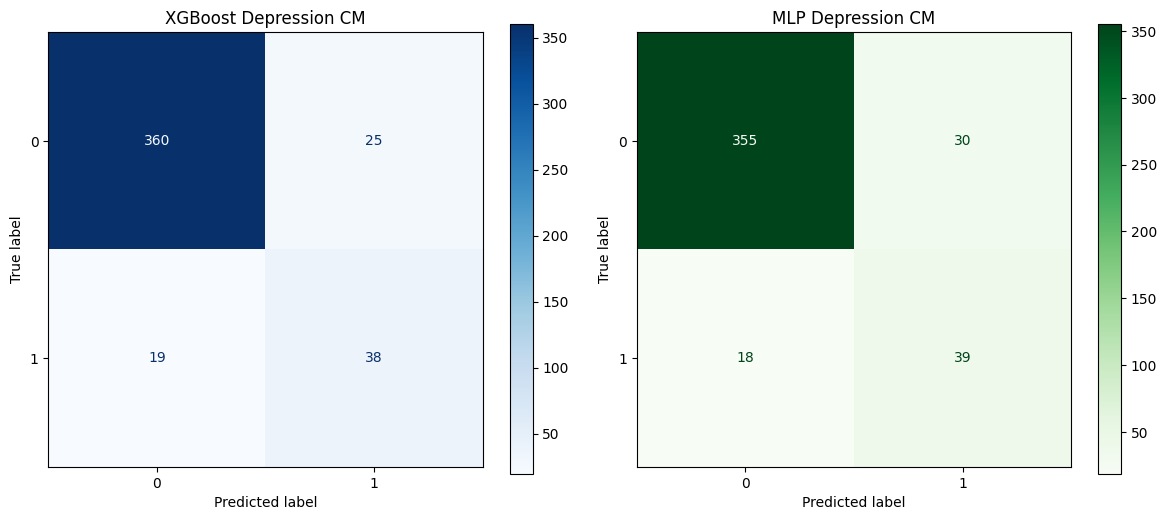

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(xgb_dep, X2_test_numeric, y2_test_clf, ax=ax[0], cmap='Blues')
ax[0].set_title('XGBoost Depression CM')

ConfusionMatrixDisplay.from_estimator(mlp_dep, X2_test_numeric, y2_test_clf, ax=ax[1], cmap='Greens')
ax[1].set_title('MLP Depression CM')

plt.tight_layout()
plt.show()

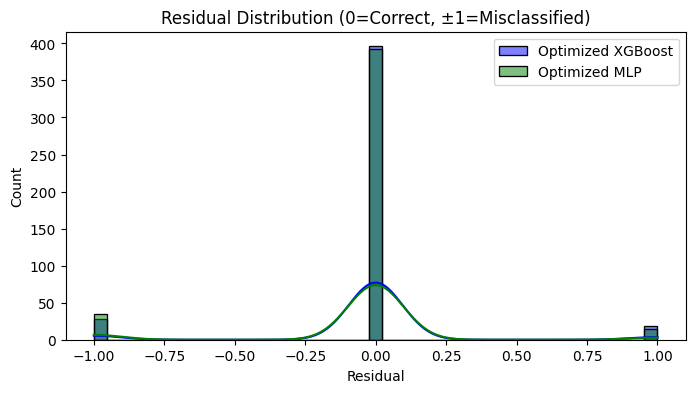

In [28]:
# Residuals for classification: (y_true - y_pred)
y_pred_xgb = xgb_best.predict(X2_test_numeric)
y_pred_mlp = mlp_optimized.predict(X2_test_numeric)

plt.figure(figsize=(8, 4))
sns.histplot(y2_test_clf - y_pred_xgb, label="Optimized XGBoost", kde=True, color='blue', alpha=0.5)
sns.histplot(y2_test_clf - y_pred_mlp, label="Optimized MLP", kde=True, color='green', alpha=0.5)

plt.legend()
plt.title("Residual Distribution (0=Correct, ±1=Misclassified)")
plt.xlabel("Residual")
plt.show()

In [29]:
# Compare the squared errors of the two optimized models statistically
t_stat, p_val = ttest_rel(
    (y2_test_clf - y_pred_xgb)**2,
    (y2_test_clf - y_pred_mlp)**2
)

print(f"T-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("There is a statistically significant difference in performance between the two models.")
else:
    print("There is no statistically significant difference in performance between the two models.")

T-statistic: -0.8942
p-value: 0.3717
There is no statistically significant difference in performance between the two models.


In [36]:
def get_null_accuracy(y):
    return y.value_counts(normalize=True).max()

null_acc1 = get_null_accuracy(y1_test_mapped)
null_acc2 = get_null_accuracy(y2_test_clf)

print(f"Seizure Dataset Null Accuracy: {null_acc1*100:.2f}%")
print(f"Depression Dataset Null Accuracy: {null_acc2*100:.2f}%")

Seizure Dataset Null Accuracy: 20.00%
Depression Dataset Null Accuracy: 87.10%


In [31]:
# Final Classification Reports for Optimized Depression Models
print("--- Optimized XGBoost (Depression) ---")
y_pred_xgb_final = xgb_best.predict(X2_test_numeric)
print(classification_report(y2_test_clf, y_pred_xgb_final))

print("\n--- Optimized MLP (Depression) ---")
y_pred_mlp_final = mlp_optimized.predict(X2_test_numeric)
print(classification_report(y2_test_clf, y_pred_mlp_final))

--- Optimized XGBoost (Depression) ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       385
           1       0.58      0.68      0.63        57

    accuracy                           0.90       442
   macro avg       0.77      0.81      0.78       442
weighted avg       0.90      0.90      0.90       442


--- Optimized MLP (Depression) ---
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       385
           1       0.55      0.74      0.63        57

    accuracy                           0.89       442
   macro avg       0.75      0.82      0.78       442
weighted avg       0.91      0.89      0.89       442



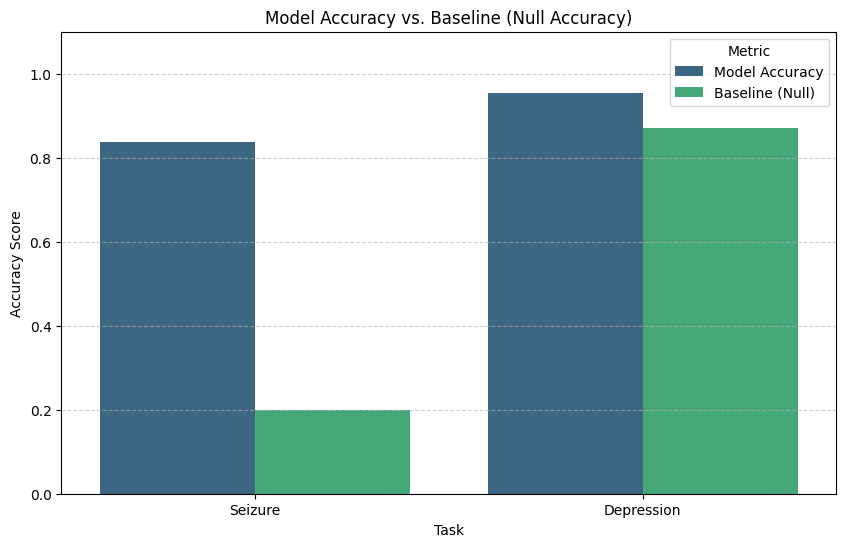

In [32]:
# Prepare data for visualization using directly available variables
plot_data = pd.DataFrame({
    'Task': ['Seizure', 'Depression'],
    'Model Accuracy': [cnn_acc,
                      accuracy_score(y2_test_clf, mlp_cat.predict(X2_test_proc))],
    'Baseline (Null)': [null_acc1, null_acc2]
})

plot_data_melted = plot_data.melt(id_vars='Task', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data_melted, x='Task', y='Score', hue='Metric', palette='viridis')
plt.title('Model Accuracy vs. Baseline (Null Accuracy)')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Final comparison
Summarize metrics and statistical tests comparing models.

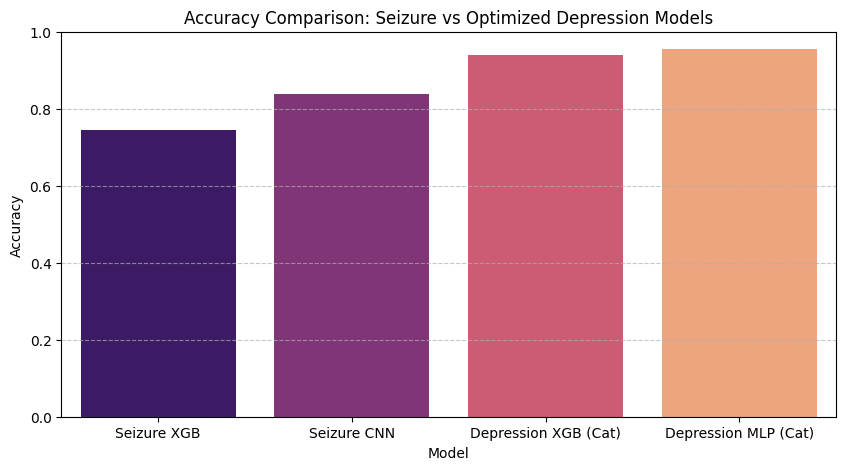

In [33]:
results = pd.DataFrame({
    "Model": ["Seizure XGB", "Seizure CNN", "Depression XGB (Cat)", "Depression MLP (Cat)"],
    "Accuracy": [
        accuracy_score(y1_test_mapped, xgb_final.predict(X1_test)),
        cnn_acc,
        accuracy_score(y2_test_clf, xgb_cat.predict(X2_test_proc)),
        accuracy_score(y2_test_clf, mlp_cat.predict(X2_test_proc))
    ]
})

plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="Accuracy", data=results, palette="magma")
plt.title("Accuracy Comparison: Seizure vs Optimized Depression Models")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()